In [1]:
import torch
import time
import numpy as np

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from model_alignment_lab.utils.helpers import generate_response, format_example
from model_alignment_lab.evaluation.eval import log_parser, evaluate_to_dataframe

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# 1. Base Model Preparation

In [2]:
MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32
)

model = model.to(device)
model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [3]:
prompt = """Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
I want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget."""

response = generate_response(model, tokenizer, prompt)
print(response)

Sure, here are the tools you requested:

1. Search Flights:
- San Diego to New York:
- 2026-05-10 to 2026-05-15
- Medium Budget

2. Search Hotels:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

3. Plan Trip:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

4. Check Weather:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

5. Search for Accommod


In [4]:
result = generate_response(
    model,
    tokenizer,
    prompt,
    max_new_tokens=80,
    benchmark=True
)
print(result["text"])
print()
print(np.round(result["total_time_s"],2))
print(np.round(result["generated_tokens"],2))
print(np.round(result["tokens_per_second"],2))

Sure, here are the tools you requested:

1. Search Flights:
- San Diego to New York:
- 2026-05-10 to 2026-05-15
- Medium Budget

2. Search Hotels:
- San Diego:
- 2026-05-10 to

1.99
80
40.17


# 2. LoRA Finetune 

In [5]:
curr_dir = Path.cwd()
curr_dir.is_dir()

True

In [6]:
output_dir = curr_dir.parent/"outputs"/"models"
output_dir.is_dir()

True

In [7]:
[item for item in curr_dir.parent.iterdir()]

[WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/.git'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/.gitignore'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/.python-version'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/.venv'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/LICENSE'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/main.py'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/models'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/notebooks'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/outputs'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/pyproject.toml'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/

In [8]:
datasets_dir = curr_dir.parent/"datasets"/"structured_json"
datasets_dir.is_dir()

True

In [9]:
[item for item in datasets_dir.iterdir()]

[WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/TEST_travel_tool_routing_20_samples.jsonl'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/TEST_travel_tool_routing_20_samples_prompted_v2.jsonl'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/TRAIN_travel_tool_routing_100_samples.jsonl'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/TRAIN_travel_tool_routing_100_samples_prompted_v2.jsonl'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/VAL_travel_tool_routing_20_samples.jsonl'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/VAL_travel_tool_routing_20_samples_prompted_v2.jsonl')]

In [10]:
train_path = datasets_dir.joinpath("TRAIN_travel_tool_routing_100_samples_prompted_v2.jsonl") #datasets_dir.joinpath("TRAIN_travel_tool_routing_100_samples.jsonl")
train_path.is_file()

True

In [11]:
test_path = datasets_dir.joinpath("TEST_travel_tool_routing_20_samples_prompted_v2.jsonl")
test_path.is_file()

True

In [12]:
val_path = datasets_dir.joinpath("VAL_travel_tool_routing_20_samples_prompted_v2.jsonl")
val_path.is_file()

True

## Load the Dataset

In [13]:
from datasets import load_dataset

train_dataset = load_dataset("json", 
                             data_files={
                                 "train": str(train_path)
                             }
                            )["train"]
test_dataset = load_dataset("json",
                            data_files={
                                "test": str(test_path)
                            }
                           )["test"]
val_dataset = load_dataset("json",
                           data_files={
                               "val":str(val_path)
                           }
                          )["val"]

In [14]:
train_dataset

Dataset({
    features: ['messages'],
    num_rows: 100
})

In [15]:
val_dataset

Dataset({
    features: ['messages'],
    num_rows: 20
})

In [16]:
test_dataset

Dataset({
    features: ['messages'],
    num_rows: 20
})

In [17]:
train_dataset["messages"][1]

[{'role': 'user',
  'content': 'Return ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nCheck flights from Los Angeles to Tokyo for a trip starting 2026-07-12 and ending 2026-07-18. Use the travel tool schema.'},
 {'role': 'assistant',
  'content': '{"tool": "search_flights", "arguments": {"origin": "Los Angeles", "destination": "Tokyo", "departure_date": "2026-07-12", "return_date": "2026-07-18"}}'}]

In [18]:
train_dataset = train_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
val_dataset = val_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
test_dataset = test_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

In [19]:
train_dataset

Dataset({
    features: ['messages', 'text'],
    num_rows: 100
})

In [20]:
print(train_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Quick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}<|im_end|>



In [21]:
print(val_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Please help. Can you create a trip plan for Vancouver from 2026-08-21 through 2026-08-26 on a high budget? Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "plan_trip", "arguments": {"destination": "Vancouver", "start_date": "2026-08-21", "end_date": "2026-08-26", "budget_level": "HIGH"}}<|im_end|>



In [22]:
for i in [0, 5, 10]:
    print("=" * 80)
    print(train_dataset["text"][i])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Quick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}<|im_end|>

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- c

In [23]:
print(repr(train_dataset["text"][0]))

'<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nReturn ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nQuick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.<|im_end|>\n<|im_start|>assistant\n{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}<|im_end|>\n'


### LoRA Setup

In [24]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj"]
)


In [25]:
model = get_peft_model(model, peft_config).to(model.device)
model.train()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [26]:
model.print_trainable_parameters()

trainable params: 1,638,400 || all params: 363,459,520 || trainable%: 0.4508


## Training

In [27]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir=str(output_dir/"smollm-tool-routing-lora"),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    dataset_text_field="text",
    use_cpu=False,
    bf16=False,
    fp16=False,
)

In [28]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

Tokenizing train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

In [29]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.419923,1.362777
2,0.849387,0.820194
3,0.613803,0.609836


TrainOutput(global_step=75, training_loss=1.1403102684020996, metrics={'train_runtime': 62.6252, 'train_samples_per_second': 4.79, 'train_steps_per_second': 1.198, 'total_flos': 125084943705600.0, 'train_loss': 1.1403102684020996})

In [30]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [31]:
from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
final_path = str(output_dir/"smollm-tool-routing-lora")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_time_check")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_time_check")

('C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_161534_final_adapter_time_check\\tokenizer_config.json',
 'C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_161534_final_adapter_time_check\\chat_template.jinja',
 'C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_161534_final_adapter_time_check\\tokenizer.json')

## Model Evaluation

In [32]:
trainer.state.log_history

[{'loss': 1.9274728775024415,
  'grad_norm': 0.07146608084440231,
  'learning_rate': 0.00018933333333333335,
  'entropy': 1.454178363084793,
  'num_tokens': 4383.0,
  'mean_token_accuracy': 0.6604210793972015,
  'epoch': 0.2,
  'step': 5},
 {'loss': 1.7951698303222656,
  'grad_norm': 0.0817381963133812,
  'learning_rate': 0.00017600000000000002,
  'entropy': 1.465679794549942,
  'num_tokens': 8816.0,
  'mean_token_accuracy': 0.6701938211917877,
  'epoch': 0.4,
  'step': 10},
 {'loss': 1.6740169525146484,
  'grad_norm': 0.09553121030330658,
  'learning_rate': 0.00016266666666666667,
  'entropy': 1.4999884068965912,
  'num_tokens': 13317.0,
  'mean_token_accuracy': 0.6873893201351166,
  'epoch': 0.6,
  'step': 15},
 {'loss': 1.5832510948181153,
  'grad_norm': 0.11496545374393463,
  'learning_rate': 0.00014933333333333335,
  'entropy': 1.558459758758545,
  'num_tokens': 17587.0,
  'mean_token_accuracy': 0.7075649440288544,
  'epoch': 0.8,
  'step': 20},
 {'loss': 1.4199231147766114,
  'gr

In [33]:
len(trainer.state.log_history)

19

In [34]:
epoch,loss,eval_loss = log_parser(trainer)

print(epoch)
print(loss)
print(eval_loss)

[1.0, 2.0, 3.0]
[1.4199231147766114, 0.8493867874145508, 0.6138029575347901]
[1.362776517868042, 0.8201939463615417, 0.6098363995552063]


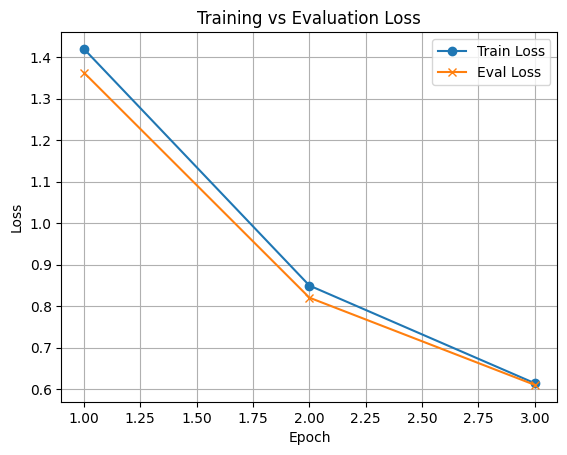

In [35]:
import matplotlib.pyplot as plt

figure, ax = plt.subplots()
ax.plot(epoch, loss, marker="o", label="Train Loss")
ax.plot(epoch, eval_loss, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [36]:
prompt = """Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
I want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget."""

response = generate_response(model, tokenizer, prompt)
print(response)

{"tool": "search_flights", "arguments": {"origin": "San Diego", "destination": "New York", "departure_date": "2026-05-10", "return_date": "2026-05-15"}}


In [37]:
print(test_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Travel request: I want an itinerary for London from 2026-05-10 to 2026-05-15 with high spending. Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "plan_trip", "arguments": {"destination": "London", "start_date": "2026-05-10", "end_date": "2026-05-15", "budget_level": "HIGH"}}<|im_end|>



In [38]:
df = evaluate_to_dataframe(model, tokenizer, test_dataset)
df.head()

,prompt,pred_tool,actual_tool,tool_match,pred_arguments,actual_arguments,arguments_match,valid_json,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_flights,plan_trip,False,"{'origin': 'London', 'destination': 'London', ...","{'destination': 'London', 'start_date': '2026-...",False,True,"{""tool"": ""search_flights"", ""arguments"": {""orig...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
1,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'Rome', 'start_date': '2026-09...","{'destination': 'Rome', 'start_date': '2026-09...",False,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
2,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,None,"{'location': 'Honolulu', 'check_in_date': '202...",False,True,"{""tool"": ""search_hotels"", ""argument"": ""locatio...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
3,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,None,"{'location': 'New York', 'check_in_date': '202...",False,True,"{""tool"": ""search_hotels"", ""argument"": ""New Yor...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
4,Return ONLY valid JSON.\n\nAvailable tools:\n-...,weather_schemalike,check_weather,False,None,"{'location': 'Paris', 'date': '2026-08-21'}",False,True,"{""tool"": ""weather_schemalike"", ""argument_keys""...","{""tool"": ""check_weather"", ""arguments"": {""locat..."


In [39]:
df.tool_match.value_counts()

tool_match
True     14
False     6
Name: count, dtype: int64

In [40]:
df.arguments_match.value_counts()

arguments_match
False    14
True      6
Name: count, dtype: int64

In [41]:
df.valid_json.value_counts()

valid_json
True    20
Name: count, dtype: int64

## Train mas

In [42]:
# Increase number of epochs
trainer.args.num_train_epochs = 6
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.281233,0.277407
2,0.187492,0.205872
3,0.175001,0.174428
4,0.149345,0.163854
5,0.152804,0.154723
6,0.140966,0.153331


TrainOutput(global_step=150, training_loss=0.20245070457458497, metrics={'train_runtime': 121.0332, 'train_samples_per_second': 4.957, 'train_steps_per_second': 1.239, 'total_flos': 250169887411200.0, 'train_loss': 0.20245070457458497})

## Model v2 Eval

In [43]:
epoch,loss,eval_loss = log_parser(trainer)

print(epoch)
print(loss)
print(eval_loss)

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
[0.2812328338623047, 0.18749159574508667, 0.1750008463859558, 0.14934531450271607, 0.15280351638793946, 0.14096580743789672]
[0.2774069309234619, 0.2058720588684082, 0.17442840337753296, 0.16385377943515778, 0.154722660779953, 0.15333059430122375]


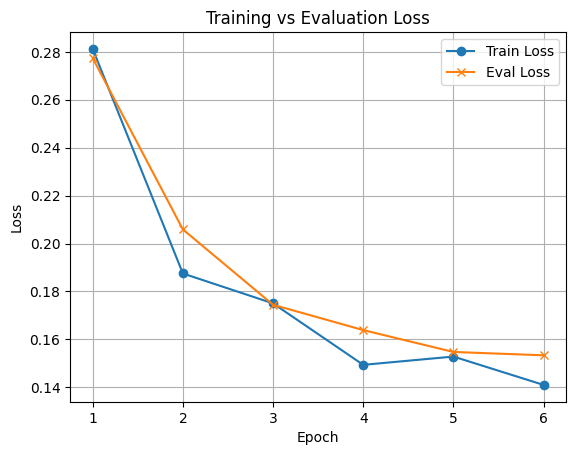

In [44]:
figure, ax = plt.subplots()
ax.plot(epoch, loss, marker="o", label="Train Loss")
ax.plot(epoch, eval_loss, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [45]:
prompt = """Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
I want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget."""

generate_response(model, tokenizer, prompt)

'{"tool": "plan_trip", "arguments": {"destination": "New York", "start_date": "2026-05-10", "end_date": "2026-05-15", "budget_level": "MEDIUM"}}'

In [46]:
df_2 = evaluate_to_dataframe(model, tokenizer, test_dataset)
df_2.head()

,prompt,pred_tool,actual_tool,tool_match,pred_arguments,actual_arguments,arguments_match,valid_json,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'London', 'start_date': '2026-...","{'destination': 'London', 'start_date': '2026-...",True,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
1,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'Rome', 'start_date': '2026-09...","{'destination': 'Rome', 'start_date': '2026-09...",True,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
2,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'Honolulu', 'check_in_date': '202...","{'location': 'Honolulu', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
3,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'New York', 'check_in_date': '202...","{'location': 'New York', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
4,Return ONLY valid JSON.\n\nAvailable tools:\n-...,check_weather,check_weather,True,"{'location': 'Paris', 'date': '2026-08-21'}","{'location': 'Paris', 'date': '2026-08-21'}",True,True,"{""tool"": ""check_weather"", ""arguments"": {""locat...","{""tool"": ""check_weather"", ""arguments"": {""locat..."


In [47]:
df_2.tool_match.value_counts()

tool_match
True    20
Name: count, dtype: int64

In [48]:
df_2.arguments_match.value_counts()

arguments_match
True    20
Name: count, dtype: int64

In [49]:
df_2.valid_json.value_counts()

valid_json
True    20
Name: count, dtype: int64

In [50]:
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
final_path = str(output_dir/"smollm-tool-routing-lora")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v2_timecheck")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v2_timecheck")

('C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_161854_final_adapter_v2_timecheck\\tokenizer_config.json',
 'C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_161854_final_adapter_v2_timecheck\\chat_template.jinja',
 'C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_161854_final_adapter_v2_timecheck\\tokenizer.json')